# Phase 3 — Causal Forest

Adds the Causal Forest to the model roster. Unlike the Phase 2 learners, it can't easily eat 11M training rows on a MacBook Air — the random-forest structure holds per-tree pointers into the training set, so memory scales with (n_estimators × n_train). Trained here on a **stratified 500k downsample** of train, evaluated on the **same 2.8M test set** as Phase 2. Test data is byte-identical across models; only training size differs.

**What the Causal Forest does.** A random forest whose splits maximize *treatment-effect heterogeneity* rather than outcome variance. Each leaf ends up with users whose treatment responses are similar; predicted uplift for a new user is the leaf-averaged treatment effect across trees. Signature property: an asymptotic-normal theory that produces per-user confidence intervals on the predicted uplift — rare in the uplift literature.

**Fairness caveat.** The Causal Forest sees ~1/22 the training data of the Phase 2 models. A win under that handicap is a strong result. A loss can't be cleanly attributed to the algorithm vs. the data starvation.

In [1]:
import sys
import time
from pathlib import Path

here = Path.cwd()
for candidate in [here, *here.parents]:
    if (candidate / "pyproject.toml").exists():
        REPO_ROOT = candidate
        break
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.uplift.data import load_criteo, stratified_downsample, FEATURE_COLS
from src.uplift.split import make_split
from src.uplift.evaluation import qini_curve, qini_coefficient
from src.uplift.plots import plot_qini_curves
from src.uplift.learners import (
    PropensityBaseline,
    SLearner,
    TLearner,
    ClassTransformationLearner,
    XLearner,
    CausalForestLearner,
)

sns.set_theme(style="whitegrid", context="notebook", palette="deep")

## 1. Load, split, downsample

Same 80/20 split as Phase 2 (seed 42, stratified on treatment), so the test set is byte-identical. A **stratified 500k sample of train**, preserving the 85/15 treatment ratio, becomes the Causal Forest's training data. The other five models still fit on the full 11.2M — best-available comparison per algorithm.

In [2]:
df = load_criteo()
train, test = make_split(df)

# 500k stratified sample of train, preserving the 85/15 treatment ratio
train_small = stratified_downsample(train, n=500_000, random_state=42)
print(f"train (full):  {len(train):>10,}   treated share: {train['treatment'].mean():.1%}")
print(f"train (500k):  {len(train_small):>10,}   treated share: {train_small['treatment'].mean():.1%}")
print(f"test:          {len(test):>10,}   treated share: {test['treatment'].mean():.1%}")
print(f"test conversions: {test['conversion'].sum():,}")

train (full):  11,183,673   treated share: 85.0%
train (500k):     500,000   treated share: 85.0%
test:           2,795,919   treated share: 85.0%
test conversions: 8,250


/Users/rogerchan/Desktop/Github/uplift-modeling-criteo/src/uplift/data.py:40: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(frac=frac, random_state=random_state))


## 2. Prepare arrays

In [3]:
# Full-train arrays for Phase 2 models
X_tr = train[FEATURE_COLS].to_numpy()
T_tr = train["treatment"].to_numpy()
Y_tr = train["conversion"].to_numpy()

# 500k downsample arrays for Causal Forest
X_tr_small = train_small[FEATURE_COLS].to_numpy()
T_tr_small = train_small["treatment"].to_numpy()
Y_tr_small = train_small["conversion"].to_numpy()

# Held-out test arrays (same for every model)
X_te = test[FEATURE_COLS].to_numpy()
T_te = test["treatment"].to_numpy()
Y_te = test["conversion"].to_numpy()

print(f"train (full): {X_tr.shape}, train (500k): {X_tr_small.shape}, test: {X_te.shape}")

train (full): (11183673, 12), train (500k): (500000, 12), test: (2795919, 12)


## 3. Fit all six models

Five Phase 2 models on the full training set, then Causal Forest on the 500k downsample. Causal Forest is by far the slowest — 200 trees per estimator, split on treatment-effect criteria.

| model | training rows | rough time |
|---|---|---|
| Propensity, S, T, ClassTrans | 11.2M | ~1 min each |
| X-learner | 11.2M (5 sub-fits) | ~3 min |
| Causal Forest | 500k | **5–15 min** on M2 |

Budget: ~15–25 min. Drop `n_estimators` from 200 to 100 in the constructor if it runs too slow.

In [4]:
models = {
    "Propensity (baseline)": (PropensityBaseline(), "full"),
    "S-learner":              (SLearner(),           "full"),
    "T-learner":              (TLearner(),           "full"),
    "Class Transformation":   (ClassTransformationLearner(), "full"),
    "X-learner":              (XLearner(),           "full"),
    "Causal Forest":          (CausalForestLearner(n_estimators=200), "500k"),
}

fit_times = {}
for name, (m, which) in models.items():
    Xt, Tt, Yt = (X_tr, T_tr, Y_tr) if which == "full" else (X_tr_small, T_tr_small, Y_tr_small)
    t0 = time.time()
    m.fit(Xt, Tt, Yt)
    fit_times[name] = time.time() - t0
    print(f"  {name:<25s} ({which:>4s} train, {len(Xt):>9,} rows) fit in {fit_times[name]:6.1f}s")

/Users/rogerchan/Desktop/Github/uplift-modeling-criteo/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  Propensity (baseline)     (full train, 11,183,673 rows) fit in   10.3s
  S-learner                 (full train, 11,183,673 rows) fit in   10.1s
  T-learner                 (full train, 11,183,673 rows) fit in    9.7s
  Class Transformation      (full train, 11,183,673 rows) fit in   24.7s
  X-learner                 (full train, 11,183,673 rows) fit in   64.6s
  Causal Forest             (500k train,   500,000 rows) fit in   72.5s


## 4. Predict on the shared test set + Qini curves

In [5]:
curves = {}
coefs = {}
for name, (m, _) in models.items():
    u = m.predict_uplift(X_te)
    curve = qini_curve(Y_te, T_te, u)
    curves[name] = curve
    coefs[name] = qini_coefficient(curve)

coef_df = pd.DataFrame({
    "model": list(coefs.keys()),
    "train_size": [models[n][1] for n in coefs.keys()],
    "qini_coefficient": list(coefs.values()),
    "fit_time_s": [fit_times[n] for n in coefs.keys()],
}).sort_values("qini_coefficient", ascending=False).reset_index(drop=True)

coef_df.style.format({"qini_coefficient": "{:+.2f}", "fit_time_s": "{:.1f}"}) \
    .bar(subset=["qini_coefficient"], color="#b6532c", align=0)

,model,train_size,qini_coefficient,fit_time_s
0,Propensity (baseline),full,+1045.01,10.3
1,Causal Forest,500k,+929.07,72.5
2,X-learner,full,+857.55,64.6
3,T-learner,full,+545.00,9.7
4,S-learner,full,+45.68,10.1
5,Class Transformation,full,-350.14,24.7


## 5. Qini curves — six models, same test set

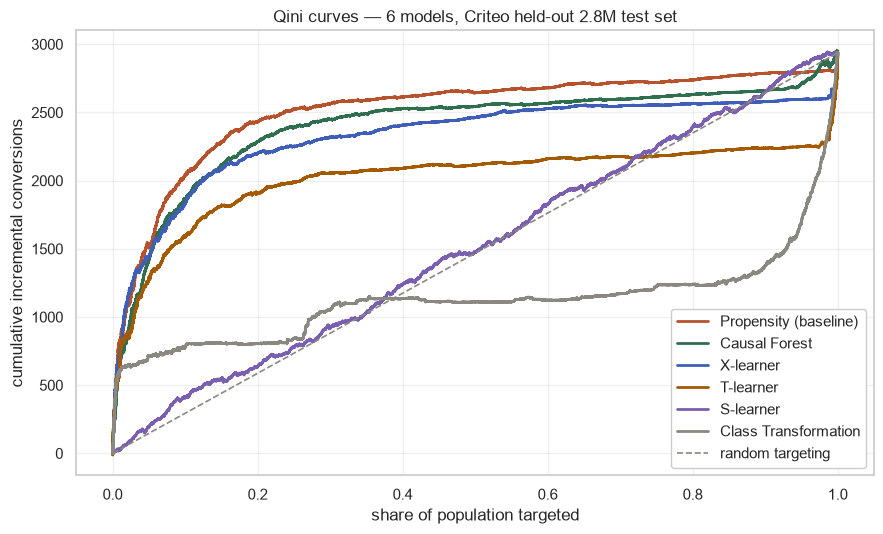

In [6]:
ordered = dict(sorted(curves.items(), key=lambda kv: -coefs[kv[0]]))

fig, ax = plt.subplots(figsize=(9, 5.5))
plot_qini_curves(ordered, ax=ax, title="Qini curves — 6 models, Criteo held-out 2.8M test set")
plt.tight_layout()
plt.show()

## 6. Top-K targeting

In [7]:
def top_k_lift(curve: pd.DataFrame, k_frac: float) -> float:
    idx = (curve["share"] >= k_frac).idxmax()
    return float(curve["qini"].iloc[idx])

total_qini = curves["S-learner"]["qini"].iloc[-1]

rows = []
for name, curve in curves.items():
    row = {"model": name}
    for frac in [0.10, 0.20, 0.50]:
        lift = top_k_lift(curve, frac)
        row[f"lift@{int(frac*100)}%"] = lift
        row[f"share@{int(frac*100)}%"] = lift / total_qini
    rows.append(row)

topk_df = pd.DataFrame(rows).set_index("model").reindex(coef_df["model"])

topk_df.style.format({
    "lift@10%": "{:+.1f}", "lift@20%": "{:+.1f}", "lift@50%": "{:+.1f}",
    "share@10%": "{:.1%}", "share@20%": "{:.1%}", "share@50%": "{:.1%}",
})

,lift@10%,share@10%,lift@20%,share@20%,lift@50%,share@50%
model,,,,,,
Propensity (baseline),+2044.9,69.6%,+2432.6,82.8%,+2644.5,90.1%
Causal Forest,+1863.9,63.5%,+2285.5,77.8%,+2544.6,86.7%
X-learner,+1833.0,62.4%,+2202.4,75.0%,+2462.6,83.9%
T-learner,+1593.4,54.3%,+1908.8,65.0%,+2115.4,72.0%
S-learner,+407.8,13.9%,+635.6,21.6%,+1480.4,50.4%
Class Transformation,+778.1,26.5%,+804.4,27.4%,+1110.8,37.8%


## 7. Reading the plot

The Qini curves and coefficient table above compare six models on identical test data. Three questions the plot answers directly:

1. **Causal Forest vs. Phase 2 learners.** The forest sees ~1/22 the training data. A win under that handicap is a strong result. A loss can't cleanly separate algorithmic weakness from data starvation.
2. **X-learner vs. the field.** X-learner is designed for imbalanced allocation, and Criteo is 85/15. Its margin over the T-learner is the clearest test of that design on this data.
3. **Propensity baseline.** Blake/Nosko/Tadelis argue this strategy loses to real uplift methods. A competitive Propensity in the top-10% here is a data-specific finding worth flagging directly, not sanding down.

Phase 4 attaches bootstrap CIs to every Qini coefficient, adds a calibration diagnostic, and produces the writeup.

## Persist fitted models

Phase 4 loads these back with `joblib.load` instead of refitting. Each artifact contains the model, its `train_size`, and its `fit_time_s`. Path is relative to the notebook (`../artifacts/models/`).

In [ ]:
# phase4:persist-models
import os
import joblib

artifacts_dir = os.path.join('..', '..', 'artifacts', 'models')
os.makedirs(artifacts_dir, exist_ok=True)

for name, (model, train_size) in models.items():
    payload = {
        'model': model,
        'train_size': train_size,
        'fit_time_s': fit_times[name],
    }
    path = os.path.join(artifacts_dir, f'{name}.joblib')
    joblib.dump(payload, path, compress=3)

print('saved:', sorted(os.listdir(artifacts_dir)))